In [11]:

import pandas as pd
from pathlib import Path

In [242]:
ruta_carpeta=Path(r'D:\Proyectos\Python-proyecto\Proyecto_de_Python\data')

In [243]:

lista_df=[]
for path in ruta_carpeta.glob('*.csv'):
     #print(path.full_match)
     df=pd.read_csv(path)
     df['Source']=path.stem
     df['Ano']=df['Source'].str[-4:]
     lista_df.append(df)
     print(df.shape)



(4995, 14)
(5, 14)


In [244]:
lista_df[1]

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,Source,Ano
0,14996,9/5/2035,1289,Clothing,West,2,371.74,0.27,COD,3,2.3,542.74,ecommerce_2026,2026
1,14997,9/6/2035,1294,Beauty,North,3,553.67,0.14,COD,11,2.2,1428.47,ecommerce_2026,2026
2,14998,9/7/2035,1450,Beauty,West,3,77.22,0.24,Wallet,6,3.4,176.06,ecommerce_2026,2026
3,14999,9/8/2035,1903,Electronics,South,4,138.41,0.21,COD,4,2.8,437.38,ecommerce_2026,2026
4,15000,9/9/2035,1214,Home,East,7,231.58,0.34,COD,5,3.9,1069.90,ecommerce_2026,2026


In [245]:
df_sales_venta=pd.concat(lista_df, ignore_index=True)

In [246]:
df_sales_venta.shape

(5000, 14)


#como cargarlo a sql
 

In [298]:

"""
Versión con SQLAlchemy
CAST
"""

import pandas as pd
from sqlalchemy import create_engine

# Configuración de la conexión con SQLAlchemy
server = 'DESKTOP-RGD0RVH' 
database = 'BD_e_commerce'
driver = 'ODBC Driver 17 for SQL Server'

# Cadena de conexión para SQL Server con autenticación de Windows
conn_str = f'mssql+pyodbc://{server}/{database}?trusted_connection=yes&driver={driver}'

# Crear el engine
engine = create_engine(conn_str)

# Asumiendo que df ya está cargado desde una celda anterior
# Si no, descomenta las siguientes líneas:
# df = pd.read_sql("SELECT * FROM Ventas_Diarias", engine)
# # Aplicar transformaciones si es necesario
# if 'Total' in df.columns:
#     df["TotalConIGV"] = df["Total"] * 1.18
#     df.rename(columns={"Total": "TotalSinIGV"}, inplace=True)

# Insertar los datos en la tabla
df_sales_venta.to_sql('df_sales_venta', engine, if_exists='append', index=False)

print(f"Se insertaron {len(df_sales_venta)} filas en la tabla sales_ecommerce")


Se insertaron 5000 filas en la tabla sales_ecommerce


In [249]:
df_sales_venta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
 12  Source            5000 non-null   object 
 13  Ano               5000 non-null   object 
dtypes: float64(4), int64(4), object(6)
memory usage: 547.0+ KB


In [250]:
df_sales_venta.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,Source,Ano
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,ecommerce_2025,2025
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,ecommerce_2025,2025
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,ecommerce_2025,2025
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,ecommerce_2025,2025
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,ecommerce_2025,2025


In [251]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue', 'Source', 'Ano'],
      dtype='object')

In [252]:
df.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
Source              0
Ano                 0
dtype: int64

analizando valores nulos

In [254]:
df_sales_venta

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,Source,Ano
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,ecommerce_2025,2025
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,ecommerce_2025,2025
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,ecommerce_2025,2025
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,ecommerce_2025,2025
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,ecommerce_2025,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,14996,9/5/2035,1289,Clothing,West,2,371.74,0.27,COD,3,2.3,542.74,ecommerce_2026,2026
4996,14997,9/6/2035,1294,Beauty,North,3,553.67,0.14,COD,11,2.2,1428.47,ecommerce_2026,2026
4997,14998,9/7/2035,1450,Beauty,West,3,77.22,0.24,Wallet,6,3.4,176.06,ecommerce_2026,2026
4998,14999,9/8/2035,1903,Electronics,South,4,138.41,0.21,COD,4,2.8,437.38,ecommerce_2026,2026


In [255]:
df_sales_venta.duplicated().sum()

np.int64(0)

In [256]:
df_sales_venta_clean=df_sales_venta.copy()

In [257]:
"""
Versión con SQLAlchemy
CAST
"""

import pandas as pd
from sqlalchemy import create_engine

# Configuración de la conexión con SQLAlchemy
server = 'DESKTOP-RGD0RVH' 
database = 'BD_e_commerce'
driver = 'ODBC Driver 17 for SQL Server'

# Cadena de conexión para SQL Server con autenticación de Windows
conn_str = f'mssql+pyodbc://{server}/{database}?trusted_connection=yes&driver={driver}'

# Crear el engine
engine = create_engine(conn_str)

# Asumiendo que df ya está cargado desde una celda anterior
# Si no, descomenta las siguientes líneas:
# df = pd.read_sql("SELECT * FROM Ventas_Diarias", engine)
# # Aplicar transformaciones si es necesario
# if 'Total' in df.columns:
#     df["TotalConIGV"] = df["Total"] * 1.18
#     df.rename(columns={"Total": "TotalSinIGV"}, inplace=True)

# Insertar los datos en la tabla
df_sales_venta.to_sql('df_sales_venta_clean', engine, if_exists='append', index=False)

print(f"Se insertaron {len(df_sales_venta_clean)} filas en la tabla sales_ecommerce")

Se insertaron 5000 filas en la tabla sales_ecommerce


In [258]:
df_sales_venta.head()


,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,Source,Ano
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,ecommerce_2025,2025
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,ecommerce_2025,2025
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,ecommerce_2025,2025
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,ecommerce_2025,2025
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,ecommerce_2025,2025


In [259]:
df_sales_venta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
 12  Source            5000 non-null   object 
 13  Ano               5000 non-null   object 
dtypes: float64(4), int64(4), object(6)
memory usage: 547.0+ KB


In [311]:
# -- coding: utf-8 --
"""
Created on Fri Nov 7 12:13:17 2025
@author: Astrid
"""

import pandas as pd
import pyodbc

# --- CONFIGURACIÓN CON AUTENTICACIÓN DE WINDOWS ---
server = 'DESKTOP-RGD0RVH'
database = 'BD_e_commerce'

conn_str = (
    f'DRIVER={{ODBC Driver 17 for SQL Server}};'
    f'SERVER={server};'
    f'DATABASE={database};'
    f'Trusted_Connection=yes;'
)

try:
    conn = pyodbc.connect(conn_str)
    print("Conexión exitosa")

    # EXTRAER LOS DATOS
    df_visualizacion = pd.read_sql("select * from df_sales_venta_clean", conn) # modificar
    print("Datos extraídos")
    print(df_visualizacion.head())



except Exception as e:
    print(f"Error al conectar o procesar: {e}")

finally:
    if 'conn' in locals():
        conn.close()

Conexión exitosa


C:\Users\USER\AppData\Local\Temp\ipykernel_22832\2237532233.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_visualizacion = pd.read_sql("select * from df_sales_venta_clean", conn) # modificar


Datos extraídos
   order_id order_date  customer_id product_category region  quantity  \
0     10001   1/1/2022         1102           Beauty  South         7   
1     10002   1/2/2022         1435         Clothing  South         7   
2     10003   1/3/2022         1860           Beauty   East         3   
3     10004   1/4/2022         1270      Electronics   West         5   
4     10005   1/5/2022         1106         Clothing   West         5   

   unit_price  discount payment_method  delivery_days  customer_rating  \
0      373.65      0.28         Wallet             10              4.7   
1       47.74      0.09           Card              6              3.9   
2      311.28      0.31            COD              6              2.5   
3      524.47      0.02         Wallet              6              1.6   
4      139.87      0.33         Wallet              4              4.9   

   revenue          Source   Ano  
0  1883.20  ecommerce_2025  2025  
1   304.10  ecommerce_2025  20

In [327]:
import seaborn as sns
import matplotlib.pyplot as plt


In [303]:
df_sales_venta_clean

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,Source,Ano
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,ecommerce_2025,2025
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,ecommerce_2025,2025
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,ecommerce_2025,2025
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,ecommerce_2025,2025
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,ecommerce_2025,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,14996,9/5/2035,1289,Clothing,West,2,371.74,0.27,COD,3,2.3,542.74,ecommerce_2026,2026
4996,14997,9/6/2035,1294,Beauty,North,3,553.67,0.14,COD,11,2.2,1428.47,ecommerce_2026,2026
4997,14998,9/7/2035,1450,Beauty,West,3,77.22,0.24,Wallet,6,3.4,176.06,ecommerce_2026,2026
4998,14999,9/8/2035,1903,Electronics,South,4,138.41,0.21,COD,4,2.8,437.38,ecommerce_2026,2026


In [312]:
df_visualizacion

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,Source,Ano
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,ecommerce_2025,2025
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,ecommerce_2025,2025
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,ecommerce_2025,2025
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,ecommerce_2025,2025
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,ecommerce_2025,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,14996,9/5/2035,1289,Clothing,West,2,371.74,0.27,COD,3,2.3,542.74,ecommerce_2026,2026
19996,14997,9/6/2035,1294,Beauty,North,3,553.67,0.14,COD,11,2.2,1428.47,ecommerce_2026,2026
19997,14998,9/7/2035,1450,Beauty,West,3,77.22,0.24,Wallet,6,3.4,176.06,ecommerce_2026,2026
19998,14999,9/8/2035,1903,Electronics,South,4,138.41,0.21,COD,4,2.8,437.38,ecommerce_2026,2026


In [305]:
df_visualizacion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          20000 non-null  int64  
 1   order_date        20000 non-null  object 
 2   customer_id       20000 non-null  int64  
 3   product_category  20000 non-null  object 
 4   region            20000 non-null  object 
 5   quantity          20000 non-null  int64  
 6   unit_price        20000 non-null  float64
 7   discount          20000 non-null  float64
 8   payment_method    20000 non-null  object 
 9   delivery_days     20000 non-null  int64  
 10  customer_rating   20000 non-null  float64
 11  revenue           20000 non-null  float64
 12  Source            20000 non-null  object 
 13  Ano               20000 non-null  object 
dtypes: float64(4), int64(4), object(6)
memory usage: 2.1+ MB


In [306]:
df_visualizacion.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,Source,Ano
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,ecommerce_2025,2025
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,ecommerce_2025,2025
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,ecommerce_2025,2025
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,ecommerce_2025,2025
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,ecommerce_2025,2025


In [353]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [348]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [349]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [350]:
import seaborn as sns

In [351]:
sns.set_theme()

In [352]:
pip freeze

aiobotocore @ file:///C:/miniconda3/conda-bld/aiobotocore_1760994335546/work
aiodns @ file:///C:/miniconda3/conda-bld/aiodns_1762185075564/work
aiohappyeyeballs @ file:///C:/b/abs_f806x82huz/croot/aiohappyeyeballs_1755769855628/work
aiohttp @ file:///C:/miniconda3/conda-bld/aiohttp_1762519774760/work
aioitertools @ file:///C:/b/abs_70vydn6fmg/croot/aioitertools_1754313763510/work
aiosignal @ file:///C:/b/abs_84ej696pud/croot/aiosignal_1755870823775/work
alabaster @ file:///C:/Users/dev-admin/perseverance-python-buildout/croot/alabaster_1729041938345/work
altair @ file:///C:/b/abs_0b1avjyzoc/croot/altair_1743016738596/work
anaconda-anon-usage @ file:///opt/miniconda3/conda-bld/anaconda-anon-usage_1764636648062/work
anaconda-auth @ file:///C:/miniconda3/conda-bld/anaconda-cloud-auth-split_1765839853030/work
anaconda-catalogs @ file:///C:/miniconda3/conda-bld/anaconda-catalogs_1764859031645/work
anaconda-cli-base @ file:///C:/miniconda3/conda-bld/anaconda-cli-base_1764888883727/work
anaco

In [264]:
df_sales_venta

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,Source,Ano
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,ecommerce_2025,2025
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,ecommerce_2025,2025
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,ecommerce_2025,2025
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,ecommerce_2025,2025
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,ecommerce_2025,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,14996,9/5/2035,1289,Clothing,West,2,371.74,0.27,COD,3,2.3,542.74,ecommerce_2026,2026
4996,14997,9/6/2035,1294,Beauty,North,3,553.67,0.14,COD,11,2.2,1428.47,ecommerce_2026,2026
4997,14998,9/7/2035,1450,Beauty,West,3,77.22,0.24,Wallet,6,3.4,176.06,ecommerce_2026,2026
4998,14999,9/8/2035,1903,Electronics,South,4,138.41,0.21,COD,4,2.8,437.38,ecommerce_2026,2026


In [266]:
df_sales_venta_clean

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,Source,Ano
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,ecommerce_2025,2025
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,ecommerce_2025,2025
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,ecommerce_2025,2025
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,ecommerce_2025,2025
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,ecommerce_2025,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,14996,9/5/2035,1289,Clothing,West,2,371.74,0.27,COD,3,2.3,542.74,ecommerce_2026,2026
4996,14997,9/6/2035,1294,Beauty,North,3,553.67,0.14,COD,11,2.2,1428.47,ecommerce_2026,2026
4997,14998,9/7/2035,1450,Beauty,West,3,77.22,0.24,Wallet,6,3.4,176.06,ecommerce_2026,2026
4998,14999,9/8/2035,1903,Electronics,South,4,138.41,0.21,COD,4,2.8,437.38,ecommerce_2026,2026


preguntas

  region     revenue
3   West  1345582.16
1  North  1281508.45
2  South  1246640.90
0   East  1236044.23


C:\Users\USER\AppData\Local\Temp\ipykernel_22832\2599140118.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_region_revenue, x='region', y='revenue', palette='Blues_r')


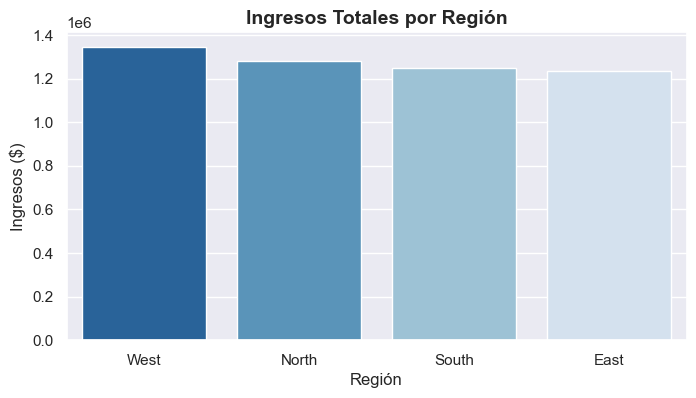

<Figure size 640x480 with 0 Axes>

In [346]:
df_region_revenue = df_sales_venta_clean.groupby('region')['revenue'].sum().reset_index()
df_region_revenue = df_region_revenue.sort_values(by='revenue', ascending=False)
print(df_region_revenue)

plt.figure(figsize=(8, 4))
sns.barplot(data=df_region_revenue, x='region', y='revenue', palette='Blues_r')
plt.title('Ingresos Totales por Región', fontsize=14, fontweight='bold')
plt.xlabel('Región')
plt.ylabel('Ingresos ($)')
plt.show()

plt.savefig('barra1')



2. ¿Cuál es el método de pago más usado al realizar las compras?

  payment_method  percentage
0           Card       45.40
1            COD       35.48
2         Wallet       19.12


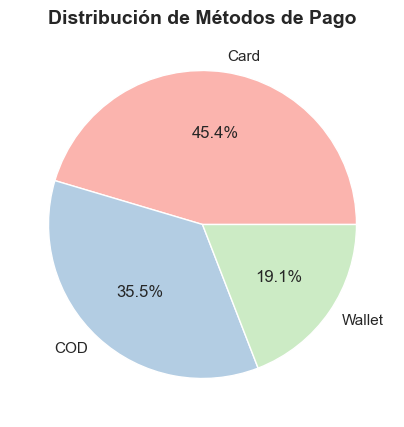

<Figure size 640x480 with 0 Axes>

In [340]:
df_payments = df_sales_venta_clean['payment_method'].value_counts(normalize=True).reset_index()
df_payments.columns = ['payment_method', 'percentage']
df_payments['percentage'] *= 100
print(df_payments)


plt.figure(figsize=(5, 5))
plt.pie(df_payments['percentage'], labels=df_payments['payment_method'], autopct='%1.1f%%', colors=sns.color_palette('Pastel1'))
plt.title('Distribución de Métodos de Pago', fontsize=14, fontweight='bold')
plt.show()


plt.savefig('grafica2')

  product_category  average_order_value
0           Beauty          1059.281992
1         Clothing          1000.608570
2      Electronics          1029.768835
3             Home          1013.502497


C:\Users\USER\AppData\Local\Temp\ipykernel_22832\3796924231.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_aov, x='average_order_value', y='product_category', palette='viridis')


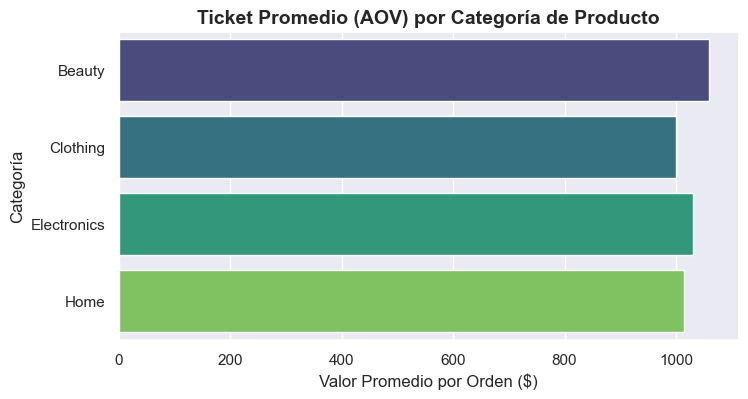

<Figure size 640x480 with 0 Axes>

In [341]:
df_aov = df_sales_venta_clean.groupby('product_category')['revenue'].mean().reset_index()
df_aov.columns = ['product_category', 'average_order_value']
print(df_aov)

plt.figure(figsize=(8, 4))
sns.barplot(data=df_aov, x='average_order_value', y='product_category', palette='viridis')
plt.title('Ticket Promedio (AOV) por Categoría de Producto', fontsize=14, fontweight='bold')
plt.xlabel('Valor Promedio por Orden ($)')
plt.ylabel('Categoría')
plt.show()


plt.savefig('grafica3')

      order_id  customer_rating satisfaction_segment
0        10001              4.7                 Alto
1        10002              3.9              Neutral
2        10003              2.5                 Bajo
3        10004              1.6                 Bajo
4        10005              4.9                 Alto
...        ...              ...                  ...
4995     14996              2.3                 Bajo
4996     14997              2.2                 Bajo
4997     14998              3.4              Neutral
4998     14999              2.8                 Bajo
4999     15000              3.9              Neutral

[5000 rows x 3 columns]


C:\Users\USER\AppData\Local\Temp\ipykernel_22832\3041343545.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sales_venta_clean, x='satisfaction_segment', order=['Bajo', 'Neutral', 'Alto'], palette='Set2')


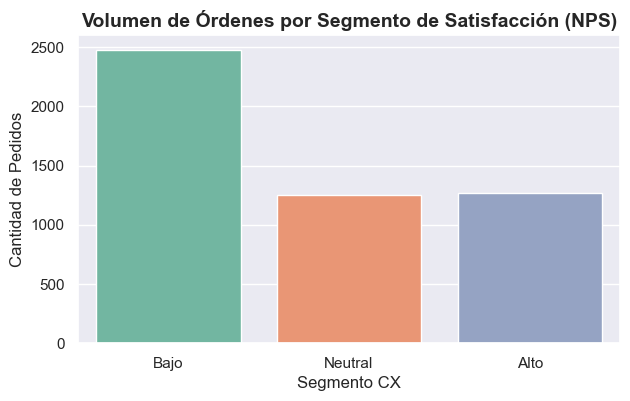

<Figure size 640x480 with 0 Axes>

In [342]:
conditions = [
    (df_sales_venta_clean['customer_rating'] < 3.0),
    (df_sales_venta_clean['customer_rating'] >= 3.0) & (df_sales_venta_clean['customer_rating'] < 4.0),
    (df_sales_venta_clean['customer_rating'] >= 4.0)
]
choices = ['Bajo', 'Neutral', 'Alto']

df_sales_venta_clean['satisfaction_segment'] = np.select(conditions, choices, default='Sin Calificar')
print(df_sales_venta_clean[['order_id', 'customer_rating', 'satisfaction_segment']])



plt.figure(figsize=(7, 4))
sns.countplot(data=df_sales_venta_clean, x='satisfaction_segment', order=['Bajo', 'Neutral', 'Alto'], palette='Set2')
plt.title('Volumen de Órdenes por Segmento de Satisfacción (NPS)', fontsize=14, fontweight='bold')
plt.xlabel('Segmento CX')
plt.ylabel('Cantidad de Pedidos')
plt.show()

plt.savefig('grafica4')



  region  avg_delivery_days  total_orders
0   East           6.104319          1227
1  North           6.118339          1276
2  South           6.173013          1208
3   West           6.082234          1289


C:\Users\USER\AppData\Local\Temp\ipykernel_22832\2164138883.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_logistic, x='region', y='avg_delivery_days', palette='coolwarm')


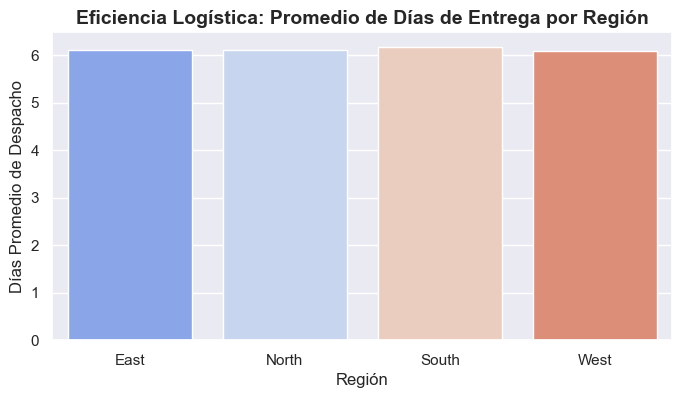

<Figure size 640x480 with 0 Axes>

In [343]:
df_logistic = df_sales_venta_clean.groupby('region').agg(
    avg_delivery_days=('delivery_days', 'mean'),
    total_orders=('order_id', 'count')
).reset_index()
print(df_logistic)



plt.figure(figsize=(8, 4))
sns.barplot(data=df_logistic, x='region', y='avg_delivery_days', palette='coolwarm')
plt.title('Eficiencia Logística: Promedio de Días de Entrega por Región', fontsize=14, fontweight='bold')
plt.xlabel('Región')
plt.ylabel('Días Promedio de Despacho')
plt.show()

plt.savefig('grafica5')



     region  rank_by_region  customer_id  revenue
3101   East               1         1699  4005.93
661    East               2         1550  3868.11
2323   East               3         1704  3757.89
1649   East               4         1475  3600.65
4728   East               5         1086  3568.81
...     ...             ...          ...      ...
1764   West            1285         1513    25.50
2143   West            1286         1053    21.13
87     West            1287         1561    14.42
1380   West            1288         1641    14.10
3435   West            1289         1793    13.78

[5000 rows x 4 columns]


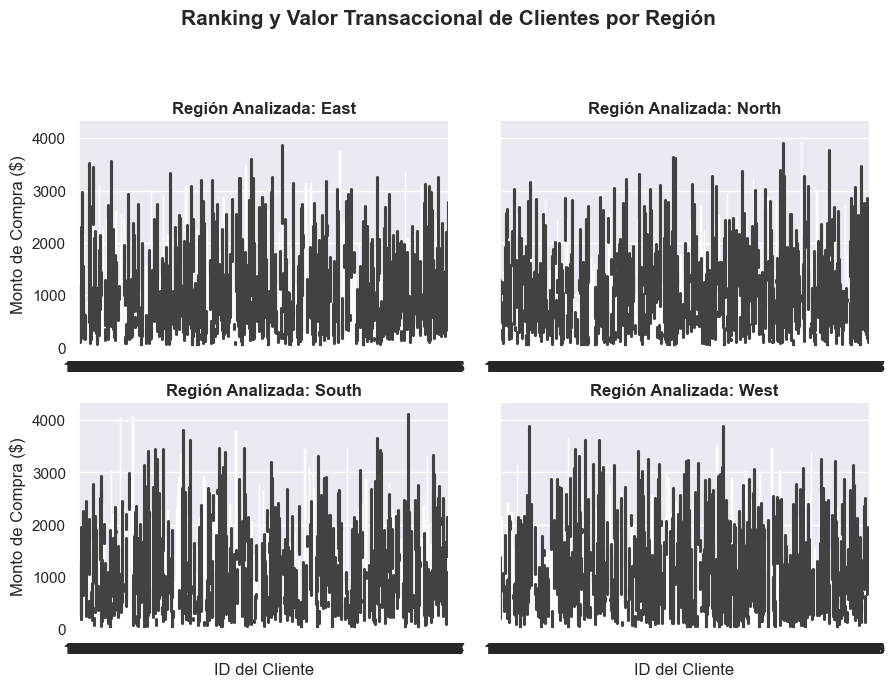

In [337]:
df_sales_venta_clean['rank_by_region'] = df_sales_venta_clean.groupby('region')['revenue'].rank(ascending=False, method='first').astype(int)


df_ranked_vip = df_sales_venta_clean.sort_values(by=['region', 'rank_by_region']).copy()
print(df_ranked_vip[['region', 'rank_by_region', 'customer_id', 'revenue']])

g = sns.FacetGrid(df_ranked_vip, col="region", col_wrap=2, sharex=False, height=3.5, aspect=1.3)
g.map_dataframe(sns.barplot, x="customer_id", y="revenue", hue="customer_id", palette="rocket", legend=False)
g.set_titles(col_template="Región Analizada: {col_name}", fontweight='bold')
g.set_axis_labels("ID del Cliente", "Monto de Compra ($)")
plt.subplots_adjust(top=0.82)
g.fig.suptitle('Ranking y Valor Transaccional de Clientes por Región', fontsize=15, fontweight='bold')
plt.show()